In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import roc_auc_score, roc_curve

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.12.0+cu126
CUDA available: True
CUDA version: 12.6
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


In [2]:
PROCESSED_DIR = Path("processed")

paths = {
    "train": PROCESSED_DIR / "processed_tracks_hitpattern_val.npz",
    "test_background": PROCESSED_DIR / "processed_tracks_hitpattern_test_background.npz",
    "test_signal": PROCESSED_DIR / "processed_tracks_hitpattern_test_signal.npz",
}

In [3]:
data_train = np.load(paths["train"], allow_pickle=True)
data_bg = np.load(paths["test_background"], allow_pickle=True)
data_sig = np.load(paths["test_signal"], allow_pickle=True)

print("Dataset caricati.")

Dataset caricati.


In [4]:
data_train = np.load(paths["train"], allow_pickle=True)
data_bg = np.load(paths["test_background"], allow_pickle=True)
data_sig = np.load(paths["test_signal"], allow_pickle=True)

print("Dataset caricati.")

Dataset caricati.


In [5]:
def describe_dataset(name, data):
    print("\n" + "=" * 80)
    print(f"DATASET: {name}")
    print("=" * 80)

    print("keys:", list(data.keys()))

    X = data["X_tracks"]
    mask = data["track_mask"]
    features = list(data["track_feature_names"])

    print("X_tracks:", X.shape, X.dtype)
    print("track_mask:", mask.shape, mask.dtype)
    print("features:", features)

    print("finite:", np.isfinite(X).all())
    print("invalid tracks zero:", np.allclose(X[~mask], 0.0))

    counts = mask.sum(axis=1)
    print("valid tracks per jet:")
    print("  min:", counts.min())
    print("  max:", counts.max())
    print("  mean:", counts.mean())
    print("  median:", np.median(counts))

    valid_values = X[mask]

    print("feature stats on valid tracks:")
    for i, feat in enumerate(features):
        vals = valid_values[:, i]
        print(
            f"{feat:35s} "
            f"mean={vals.mean(): .4f} "
            f"std={vals.std(): .4f} "
            f"min={vals.min(): .4f} "
            f"max={vals.max(): .4f}"
        )

    if "y" in data:
        print("y:", np.unique(data["y"], return_counts=True))


describe_dataset("train/val", data_train)
describe_dataset("test_background", data_bg)
describe_dataset("test_signal", data_sig)


DATASET: train/val
keys: ['X_tracks', 'track_mask', 'track_feature_names', 'y', 'meta_isDisplaced', 'meta_flavour_label', 'norm_mean_d0', 'norm_std_d0', 'norm_mean_z0SinTheta', 'norm_std_z0SinTheta', 'norm_mean_radiusOfFirstHit', 'norm_std_radiusOfFirstHit', 'norm_mean_numberOfPixelHits', 'norm_std_numberOfPixelHits', 'norm_mean_numberOfSCTHits', 'norm_std_numberOfSCTHits', 'norm_mean_numberOfInnermostPixelLayerHits', 'norm_std_numberOfInnermostPixelLayerHits']
X_tracks: (100000, 200, 6) float32
track_mask: (100000, 200) bool
features: ['d0', 'z0SinTheta', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfInnermostPixelLayerHits']
finite: True
invalid tracks zero: True
valid tracks per jet:
  min: 3
  max: 200
  mean: 64.59596
  median: 59.0
feature stats on valid tracks:
d0                                  mean= 0.0002 std= 1.0027 min=-5.7070 max= 5.7239
z0SinTheta                          mean=-0.0002 std= 1.0011 min=-6.0689 max= 6.0747
radiusOfFirstHit           

In [6]:
X_all = data_train["X_tracks"].astype(np.float32)
mask_all = data_train["track_mask"].astype(bool)

X_bg = data_bg["X_tracks"].astype(np.float32)
mask_bg = data_bg["track_mask"].astype(bool)

X_sig = data_sig["X_tracks"].astype(np.float32)
mask_sig = data_sig["track_mask"].astype(bool)

feature_names = list(data_train["track_feature_names"])

n_tracks = X_all.shape[1]
n_features = X_all.shape[2]

print("Train full:", X_all.shape)
print("Test background:", X_bg.shape)
print("Test signal:", X_sig.shape)
print("n_tracks:", n_tracks)
print("n_features:", n_features)
print("features:", feature_names)

Train full: (100000, 200, 6)
Test background: (100000, 200, 6)
Test signal: (61966, 200, 6)
n_tracks: 200
n_features: 6
features: ['d0', 'z0SinTheta', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfInnermostPixelLayerHits']


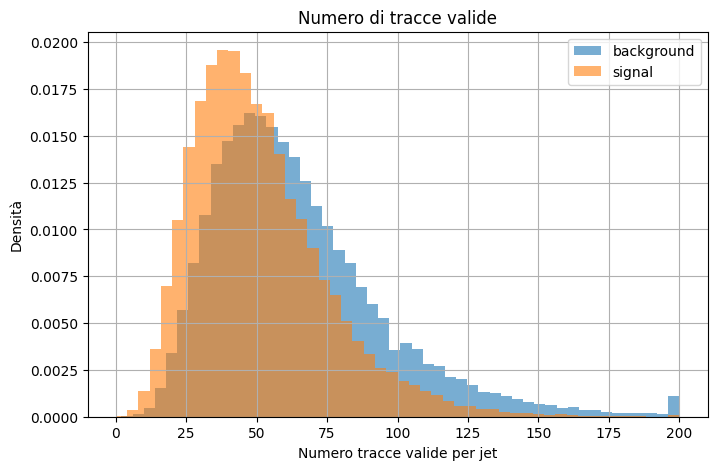

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(mask_bg.sum(axis=1), bins=50, density=True, alpha=0.6, label="background")
plt.hist(mask_sig.sum(axis=1), bins=50, density=True, alpha=0.6, label="signal")

plt.xlabel("Numero tracce valide per jet")
plt.ylabel("Densità")
plt.title("Numero di tracce valide")
plt.legend()
plt.grid(True)
plt.show()

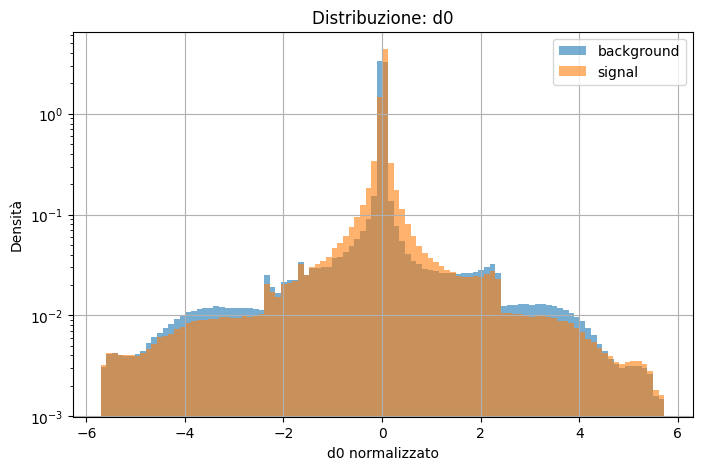

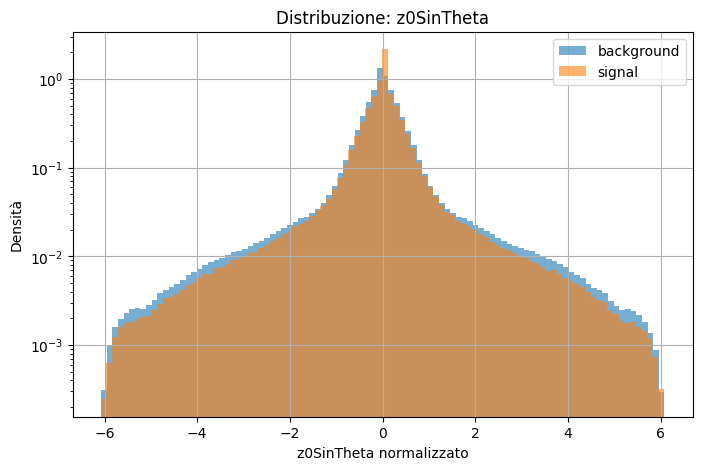

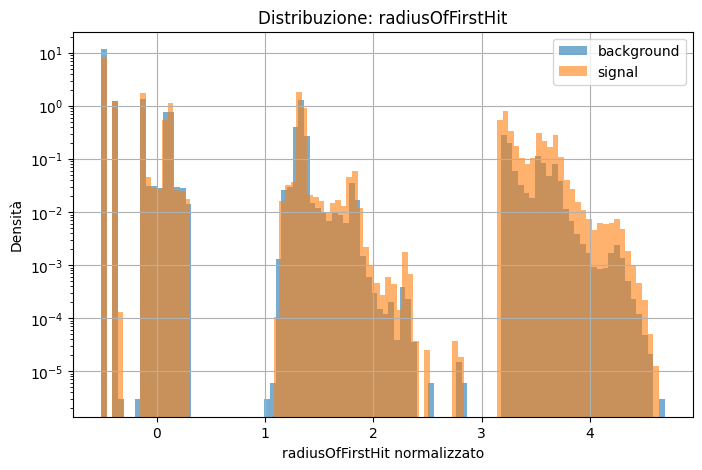

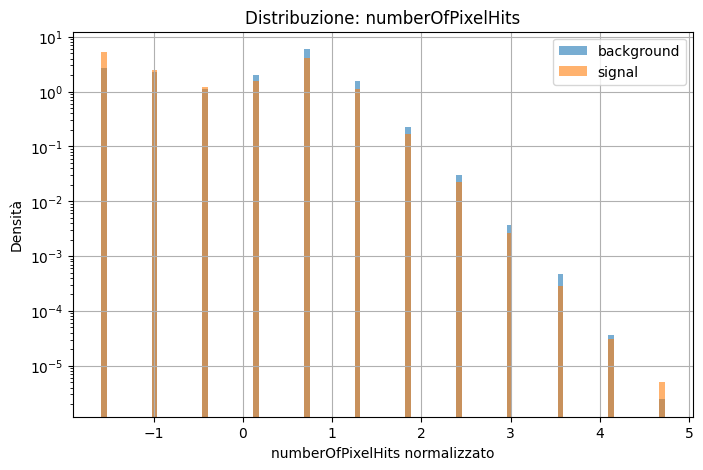

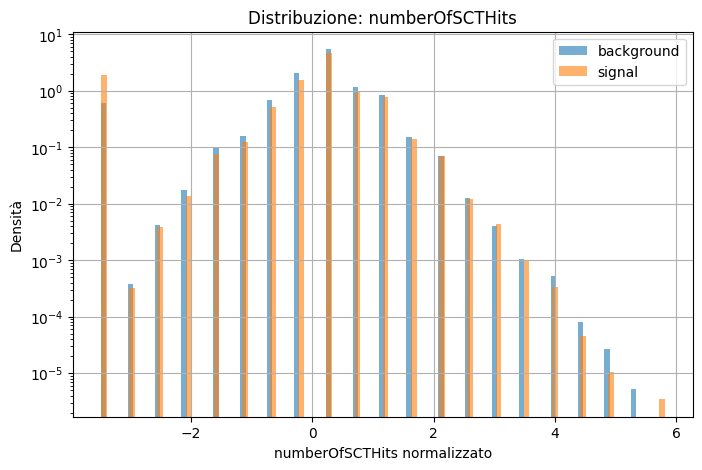

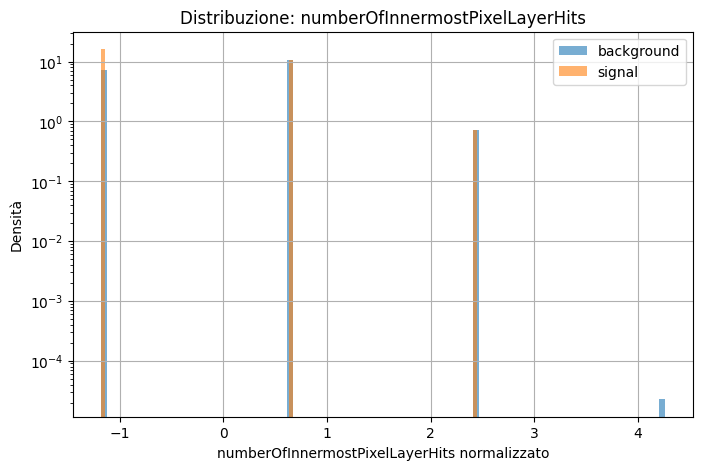

In [8]:
def plot_feature_distribution(feature_index):
    feat = feature_names[feature_index]

    bg_vals = X_bg[:, :, feature_index][mask_bg]
    sig_vals = X_sig[:, :, feature_index][mask_sig]

    plt.figure(figsize=(8, 5))
    plt.hist(bg_vals, bins=100, density=True, alpha=0.6, label="background")
    plt.hist(sig_vals, bins=100, density=True, alpha=0.6, label="signal")
    plt.yscale("log")
    plt.xlabel(f"{feat} normalizzato")
    plt.ylabel("Densità")
    plt.title(f"Distribuzione: {feat}")
    plt.legend()
    plt.grid(True)
    plt.show()


for i in range(n_features):
    plot_feature_distribution(i)

In [11]:
full_dataset = TrackDataset(X_all, mask_all)

n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

print("Train jets:", len(train_dataset))
print("Validation jets:", len(val_dataset))

Train jets: 80000
Validation jets: 20000


In [10]:
class TrackDataset(Dataset):
    def __init__(self, X, mask):
        self.X = torch.from_numpy(X).float()
        self.mask = torch.from_numpy(mask).bool()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx]

In [12]:
full_dataset = TrackDataset(X_all, mask_all)

n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

print("Train jets:", len(train_dataset))
print("Validation jets:", len(val_dataset))

Train jets: 80000
Validation jets: 20000


In [13]:
batch_size = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

In [14]:
class TrackAutoencoder(nn.Module):
    def __init__(self, n_tracks, n_features, latent_dim=32):
        super().__init__()

        self.n_tracks = n_tracks
        self.n_features = n_features

        input_dim = n_tracks * n_features

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.05),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, input_dim),
        )

    def forward(self, x):
        batch_size = x.shape[0]
        x_flat = x.reshape(batch_size, -1)
        z = self.encoder(x_flat)
        out = self.decoder(z)
        out = out.reshape(batch_size, self.n_tracks, self.n_features)
        return out

In [15]:
def masked_mse_loss(reco, x, mask):
    mask_expanded = mask.unsqueeze(-1)  # (B, 200, 1)

    diff2 = (reco - x) ** 2
    diff2 = diff2 * mask_expanded

    denom = mask_expanded.sum() * x.shape[-1]
    denom = torch.clamp(denom, min=1)

    return diff2.sum() / denom

In [16]:
latent_dim = 32

model = TrackAutoencoder(
    n_tracks=n_tracks,
    n_features=n_features,
    latent_dim=latent_dim,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

print(model)

TrackAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=1200, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=Tru

In [17]:
def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for X_batch, mask_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            mask_batch = mask_batch.to(device, non_blocking=True)

            reco = model(X_batch)
            loss = masked_mse_loss(reco, X_batch, mask_batch)

            total_loss += loss.item() * X_batch.shape[0]
            total_items += X_batch.shape[0]

    return total_loss / total_items

In [18]:
n_epochs = 1000

train_losses = []
val_losses = []

for epoch in range(n_epochs):
    model.train()

    total_train_loss = 0.0
    total_train_items = 0

    for X_batch, mask_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        mask_batch = mask_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        reco = model(X_batch)
        loss = masked_mse_loss(reco, X_batch, mask_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * X_batch.shape[0]
        total_train_items += X_batch.shape[0]

    avg_train_loss = total_train_loss / total_train_items
    avg_val_loss = evaluate_loss(model, val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1:02d}/{n_epochs} "
        f"| train loss = {avg_train_loss:.6f} "
        f"| val loss = {avg_val_loss:.6f}"
    )

Epoch 01/1000 | train loss = 0.864570 | val loss = 0.794372
Epoch 02/1000 | train loss = 0.738808 | val loss = 0.730210
Epoch 03/1000 | train loss = 0.690631 | val loss = 0.699232
Epoch 04/1000 | train loss = 0.670154 | val loss = 0.698204
Epoch 05/1000 | train loss = 0.661834 | val loss = 0.683350
Epoch 06/1000 | train loss = 0.656680 | val loss = 0.681072
Epoch 07/1000 | train loss = 0.652847 | val loss = 0.677003
Epoch 08/1000 | train loss = 0.648728 | val loss = 0.678038
Epoch 09/1000 | train loss = 0.644222 | val loss = 0.672808
Epoch 10/1000 | train loss = 0.639885 | val loss = 0.673230
Epoch 11/1000 | train loss = 0.635523 | val loss = 0.663573
Epoch 12/1000 | train loss = 0.630981 | val loss = 0.655256
Epoch 13/1000 | train loss = 0.626781 | val loss = 0.657536
Epoch 14/1000 | train loss = 0.622575 | val loss = 0.654135
Epoch 15/1000 | train loss = 0.618693 | val loss = 0.646037
Epoch 16/1000 | train loss = 0.614383 | val loss = 0.640867
Epoch 17/1000 | train loss = 0.610724 | 

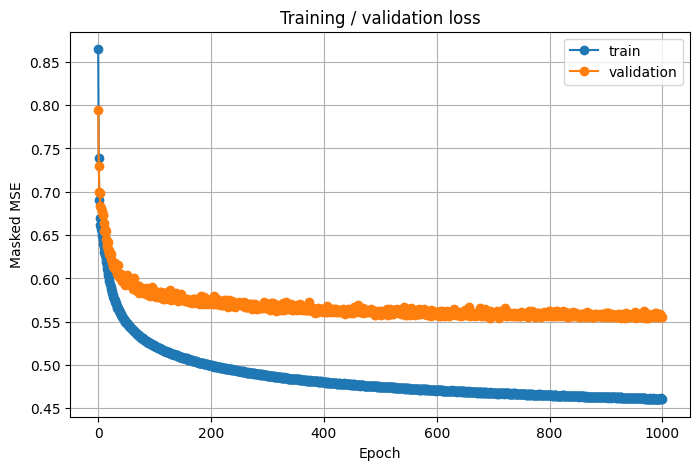

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker="o", label="train")
plt.plot(val_losses, marker="o", label="validation")
plt.xlabel("Epoch")
plt.ylabel("Masked MSE")
plt.title("Training / validation loss")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
def compute_anomaly_scores(model, X, mask, batch_size=2048):
    dataset = TrackDataset(X, mask)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()
    scores = []

    with torch.no_grad():
        for X_batch, mask_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            mask_batch = mask_batch.to(device, non_blocking=True)

            reco = model(X_batch)

            diff2 = (reco - X_batch) ** 2
            diff2 = diff2 * mask_batch.unsqueeze(-1)

            per_jet_error = diff2.sum(dim=(1, 2))

            per_jet_denom = mask_batch.sum(dim=1) * X_batch.shape[-1]
            per_jet_denom = torch.clamp(per_jet_denom, min=1)

            score = per_jet_error / per_jet_denom
            scores.append(score.cpu().numpy())

    return np.concatenate(scores)

In [21]:
scores_bg = compute_anomaly_scores(model, X_bg, mask_bg)
scores_sig = compute_anomaly_scores(model, X_sig, mask_sig)

print("scores_bg:", scores_bg.shape)
print("scores_sig:", scores_sig.shape)

print("Background mean:", scores_bg.mean())
print("Signal mean:", scores_sig.mean())

print("Background median:", np.median(scores_bg))
print("Signal median:", np.median(scores_sig))

scores_bg: (100000,)
scores_sig: (61966,)
Background mean: 0.43972883
Signal mean: 0.42589504
Background median: 0.36373675
Signal median: 0.3768782


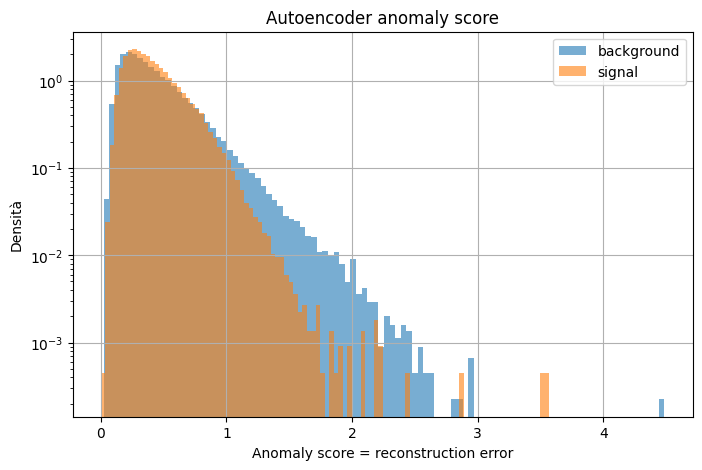

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(scores_bg, bins=100, density=True, alpha=0.6, label="background")
plt.hist(scores_sig, bins=100, density=True, alpha=0.6, label="signal")

plt.yscale("log")
plt.xlabel("Anomaly score = reconstruction error")
plt.ylabel("Densità")
plt.title("Autoencoder anomaly score")
plt.legend()
plt.grid(True)
plt.show()

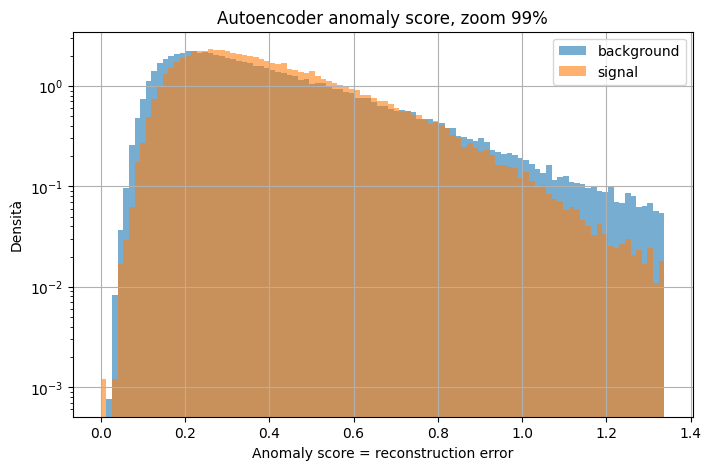

In [23]:
q99 = np.percentile(np.concatenate([scores_bg, scores_sig]), 99)

plt.figure(figsize=(8, 5))

plt.hist(scores_bg, bins=100, range=(0, q99), density=True, alpha=0.6, label="background")
plt.hist(scores_sig, bins=100, range=(0, q99), density=True, alpha=0.6, label="signal")

plt.yscale("log")
plt.xlabel("Anomaly score = reconstruction error")
plt.ylabel("Densità")
plt.title("Autoencoder anomaly score, zoom 99%")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
y_true = np.concatenate([
    np.zeros_like(scores_bg),
    np.ones_like(scores_sig),
])

y_score = np.concatenate([
    scores_bg,
    scores_sig,
])

auc = roc_auc_score(y_true, y_score)
print("AUC:", auc)

AUC: 0.5151055971823257


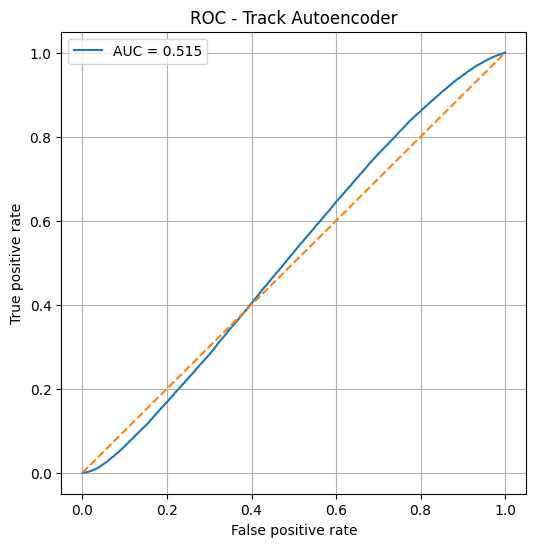

In [25]:
fpr, tpr, thresholds = roc_curve(y_true, y_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC - Track Autoencoder")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "feature_names": feature_names,
        "n_tracks": n_tracks,
        "n_features": n_features,
        "latent_dim": latent_dim,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "auc": auc,
    },
    OUT_DIR / "track_autoencoder.pt",
)

np.savez_compressed(
    OUT_DIR / "track_autoencoder_scores.npz",
    scores_bg=scores_bg,
    scores_sig=scores_sig,
    y_true=y_true,
    y_score=y_score,
    feature_names=np.array(feature_names, dtype=object),
    auc=np.array(auc, dtype=np.float32),
)

print("Salvato modello:", OUT_DIR / "track_autoencoder.pt")
print("Salvati score:", OUT_DIR / "track_autoencoder_scores.npz")

Salvato modello: outputs\track_autoencoder.pt
Salvati score: outputs\track_autoencoder_scores.npz


In [27]:
from sklearn.metrics import roc_auc_score

auc_normal = roc_auc_score(y_true, y_score)
auc_inverted = roc_auc_score(y_true, -y_score)

print("AUC normal:", auc_normal)
print("AUC inverted:", auc_inverted)
print("Best AUC:", max(auc_normal, auc_inverted))

AUC normal: 0.5151055971823257
AUC inverted: 0.4848944028176742
Best AUC: 0.5151055971823257


In [28]:
print("Background:")
print(" mean:", scores_bg.mean())
print(" median:", np.median(scores_bg))
print(" std:", scores_bg.std())

print("\nSignal:")
print(" mean:", scores_sig.mean())
print(" median:", np.median(scores_sig))
print(" std:", scores_sig.std())

print("\nQuantili background:", np.percentile(scores_bg, [1, 5, 25, 50, 75, 95, 99]))
print("Quantili signal:", np.percentile(scores_sig, [1, 5, 25, 50, 75, 95, 99]))

Background:
 mean: 0.43972883
 median: 0.36373675
 std: 0.28966916

Signal:
 mean: 0.42589504
 median: 0.3768782
 std: 0.2239476

Quantili background: [0.09103436 0.13069722 0.23143109 0.36373675 0.56897362 0.99499189
 1.44974856]
Quantili signal: [0.11321047 0.15718476 0.25920128 0.37687822 0.54558718 0.85165522
 1.10448313]


In [31]:
def aggregate_features(X, mask):
    feats = []

    # numero tracce valide
    n_valid = mask.sum(axis=1, keepdims=True).astype(np.float32)
    feats.append(n_valid)

    for i in range(X.shape[-1]):
        vals = X[:, :, i]
        valid_vals = np.where(mask, vals, np.nan)

        mean = np.nanmean(valid_vals, axis=1, keepdims=True)
        std = np.nanstd(valid_vals, axis=1, keepdims=True)
        median = np.nanmedian(valid_vals, axis=1, keepdims=True)
        q90 = np.nanpercentile(valid_vals, 90, axis=1, keepdims=True)
        maxv = np.nanmax(valid_vals, axis=1, keepdims=True)

        feats.extend([mean, std, median, q90, maxv])

    out = np.concatenate(feats, axis=1)
    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    return out.astype(np.float32)
A_bg = aggregate_features(X_bg, mask_bg)
A_sig = aggregate_features(X_sig, mask_sig)

X_clf = np.concatenate([A_bg, A_sig], axis=0)
y_clf = np.concatenate([
    np.zeros(len(A_bg)),
    np.ones(len(A_sig)),
])

C:\Users\andre\AppData\Local\Temp\ipykernel_27068\1315914045.py:12: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(valid_vals, axis=1, keepdims=True)
c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\andre\AppData\Local\Temp\ipykernel_27068\1315914045.py:14: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(valid_vals, axis=1, keepdims=True)
c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\andre\AppData\Local\Temp\ipykernel_27068\1315914045.py:16: RuntimeWarning: All-NaN slice encountered
  maxv = np.nanmax(valid_vals, axis=1, keepdims=True)


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf,
    y_clf,
    test_size=0.3,
    random_state=42,
    stratify=y_clf,
)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000),
)

clf.fit(X_tr, y_tr)

proba = clf.predict_proba(X_te)[:, 1]
auc_clf = roc_auc_score(y_te, proba)

print("Aggregate baseline AUC:", auc_clf)

Aggregate baseline AUC: 0.9301582714721178
